In [1]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/Users/samantha/QuantUS/engines/ceus/TwoD_CEUS_test
/Users/samantha/QuantUS/engines/ceus


## Select Contrast-Enhanced Ultrasound (CEUS) Cine and Parser

In [2]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['avi', 'nifti', 'mp4']


In [3]:
scan_type = 'nifti'

scan_path = '/Users/samantha/Desktop/ultrasound lab stuff/raw_ctdna/p14/wk12/combined_nifti/p14_wk12_CHI_RAW.nii'
scan_loader_kwargs = {
    'transpose': False  # Set back to False - Canon converter already rotated
    # preserve_raw will auto-detect from "_RAW" in filename
}

In [4]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, scan_path, **scan_loader_kwargs)

## Load Segmentation

Assumes same segmentation for each frame

In [5]:
from src.seg_loading.options import get_seg_loaders

print("Available segmentation loaders:", list(get_seg_loaders().keys()))

Available segmentation loaders: ['nifti', 'load_bolus_mask']


In [6]:
seg_type = 'nifti'

# ROI mask drawn on normalized data (but will be applied to raw data)
# This assumes you have a motion-corrected ROI from the Canon data
# Replace this path with your actual ROI mask file
seg_path = '/Users/samantha/Desktop/ultrasound lab stuff/raw_ctdna/p14/wk12/p14_wk12_large_roi_mc_topleft.nii.gz'
seg_loader_kwargs = {}

In [7]:
from src.entrypoints import seg_loading_step
import numpy as np

seg_data = seg_loading_step(seg_type, image_data, seg_path, scan_path, **seg_loader_kwargs)
print(seg_data.seg_mask.shape)

(604, 524, 920)


In [8]:
# # Check if mask is from combined B-mode + CEUS visualization
# print(f'Initial seg mask shape: {seg_data.seg_mask.shape}')
# print(f'Image shape: {image_data.pixel_data.shape}')

# if seg_data.seg_mask.shape[0] == 1048:
#     # Split side-by-side mask and take left half (CEUS)
#     mid = 524
#     left_half = seg_data.seg_mask[:mid, :, :]
#     right_half = seg_data.seg_mask[mid:, :, :]
    
#     # Choose half with more ROI data
#     if np.sum(left_half > 0) > np.sum(right_half > 0):
#         seg_data.seg_mask = left_half
#     else:
#         seg_data.seg_mask = right_half
    
#     print(f'After split: {seg_data.seg_mask.shape}')
    
#     # Transpose to match image orientation
#     if seg_data.seg_mask.shape != image_data.pixel_data.shape[:3]:
#         seg_data.seg_mask = seg_data.seg_mask.transpose(1, 0, 2)
#         print(f'After transpose: {seg_data.seg_mask.shape}')

# # Check if this is a motion-corrected mask (different frames) or static mask
# is_motion_corrected = seg_data.seg_mask.shape[2] == image_data.pixel_data.shape[2]

# if is_motion_corrected:
#     print(f'Motion-corrected mask detected: {seg_data.seg_mask.shape[2]} frames')
# else:
#     # If not motion-corrected, take a single representative frame
#     print(f'Static mask detected, taking single frame')
#     # Find the frame with the most ROI pixels
#     roi_counts = [np.sum(seg_data.seg_mask[:, :, i] > 0) for i in range(seg_data.seg_mask.shape[2])]
#     best_frame = np.argmax(roi_counts)
#     seg_data.seg_mask = seg_data.seg_mask[:, :, best_frame]
#     print(f'Using frame {best_frame} with {roi_counts[best_frame]} ROI pixels')
#     print(f'Final static mask shape: {seg_data.seg_mask.shape}')

# print(f'\nFinal seg mask shape: {seg_data.seg_mask.shape}')
# print(f'Image shape: {image_data.pixel_data.shape}')
# print(f'Shapes compatible: {seg_data.seg_mask.shape[:2] == image_data.pixel_data.shape[:2]}')
# print(f'ROI data loaded: {np.sum(seg_data.seg_mask > 0)} non-zero pixels')

# ============================================================================
# Load Optional Boundary Mask for Tighter T0 Map Visualization
# ============================================================================
print('\n' + '='*70)
print('BOUNDARY MASK (Optional - for tighter T0 visualization)')
print('='*70)

# Set to True to load a custom boundary mask file
USE_BOUNDARY_MASK = True

# Path to your custom boundary mask file
boundary_mask_path = '/Users/samantha/Desktop/ultrasound lab stuff/raw_ctdna/p14/wk12/p14_wk12_roi.nii.gz'

if USE_BOUNDARY_MASK:
    try:
        import nibabel as nib
        boundary_nii = nib.load(boundary_mask_path)
        boundary_mask_raw = boundary_nii.get_fdata()
        
        print(f'✓ Loaded boundary mask: {boundary_mask_path}')
        print(f'  Raw shape: {boundary_mask_raw.shape}')
        
        # Process similar to ROI mask
        if boundary_mask_raw.shape[0] == 1048:
            mid = 524
            left_half = boundary_mask_raw[:mid, :, :]
            right_half = boundary_mask_raw[mid:, :, :]
            
            if np.sum(left_half > 0) > np.sum(right_half > 0):
                boundary_mask_raw = left_half
            else:
                boundary_mask_raw = right_half
            
            print(f'  After split: {boundary_mask_raw.shape}')
            
            if boundary_mask_raw.shape != image_data.pixel_data.shape[:3]:
                boundary_mask_raw = boundary_mask_raw.transpose(1, 0, 2)
                print(f'  After transpose: {boundary_mask_raw.shape}')
        
        # Extract 2D mask
        if boundary_mask_raw.ndim == 3:
            boundary_mask_2d = boundary_mask_raw[:, :, 250] > 0
        else:
            boundary_mask_2d = boundary_mask_raw > 0
        
        print(f'  Final 2D shape: {boundary_mask_2d.shape}')
        print(f'  Boundary pixels: {np.sum(boundary_mask_2d)}')
        print(f'✓ Boundary mask loaded successfully!')
        
    except FileNotFoundError:
        print(f'⚠️  File not found: {boundary_mask_path}')
        print('   Boundary mask disabled (using full ROI)')
        boundary_mask_2d = None
        USE_BOUNDARY_MASK = False
        
    except Exception as e:
        print(f'⚠️  Error loading boundary mask: {e}')
        print('   Boundary mask disabled (using full ROI)')
        boundary_mask_2d = None
        USE_BOUNDARY_MASK = False
else:
    print('Boundary mask: DISABLED')
    print(f'  To enable: Set USE_BOUNDARY_MASK = True and provide path')
    boundary_mask_2d = None

print('='*70)


BOUNDARY MASK (Optional - for tighter T0 visualization)
✓ Loaded boundary mask: /Users/samantha/Desktop/ultrasound lab stuff/raw_ctdna/p14/wk12/p14_wk12_roi.nii.gz
  Raw shape: (1048, 604, 920)
  After split: (524, 604, 920)
  After transpose: (604, 524, 920)
  Final 2D shape: (604, 524)
  Boundary pixels: 73971
✓ Boundary mask loaded successfully!


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from matplotlib.animation import FFMpegWriter
from pathlib import Path

# Handle both 3D (NIfTI) and 4D (mp4) data
if image_data.pixel_data.ndim == 4:
    frames = image_data.pixel_data[:,:,:,0]
else:
    frames = image_data.pixel_data

seg_mask = seg_data.seg_mask

print(f"Original data shape: {frames.shape}")
print(f"Original data dtype: {frames.dtype}")
print(f"Original data range: [{frames.min():.4f}, {frames.max():.4f}]")
print(f"Original data mean: {frames.mean():.4f}")

# Normalize frames for visualization only (raw data preserved for analysis)
frames_for_display = frames.copy()

# Always normalize for display
vmin = np.percentile(frames, 0.1)  # Use 0.1 percentile
vmax = np.percentile(frames, 99.9)  # Use 99.9 percentile
print(f"Percentiles: p0.1={vmin:.4f}, p99.9={vmax:.4f}")

frames_for_display = np.clip(frames_for_display, vmin, vmax)
frames_for_display = ((frames_for_display - vmin) / (vmax - vmin) * 255).astype(np.uint8)
print(f"Normalized data range: [{frames_for_display.min()}, {frames_for_display.max()}]")

frame_slider = widgets.IntSlider(
    value=250,
    min=0,
    max=frames.shape[2] - 1,
    step=1,
    description='Frame',
    continuous_update=False,
    layout=widgets.Layout(width='600px')
)

overlay_toggle = widgets.ToggleButton(
    value=True,
    description='Show ROI',
    icon='eye',
)

output = widgets.Output()

def _select_seg_frame(frame_idx: int):
    if seg_mask.ndim == 3 and seg_mask.shape[2] == frames.shape[2]:
        return seg_mask[:,:,frame_idx]
    return seg_mask

def _render_frame(change=None):
    with output:
        output.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 8))
        
        frame_to_show = frames_for_display[:, :, frame_slider.value]
        print(f"Rendering frame {frame_slider.value}: shape={frame_to_show.shape}, range=[{frame_to_show.min()}, {frame_to_show.max()}]")
        
        ax.imshow(frame_to_show, cmap='gray', vmin=0, vmax=255)
        
        if overlay_toggle.value:
            roi_mask = _select_seg_frame(frame_slider.value)
            if np.any(roi_mask > 0):
                ax.imshow(roi_mask, alpha=0.5, cmap='Reds', vmin=0, vmax=1)
        
        ax.set_title(f"{seg_data.seg_name} - Frame {frame_slider.value}")
        ax.axis('off')
        plt.show()


def export_video_with_roi(
    frames,
    seg_mask,
    seg_name,
    output_path,
    progress_bar=None,
    status_label=None,
    fps=30,
    show_overlay=True,
    alpha=0.5,
    start_frame=0,
    end_frame=None
):
    """
    Export frames with optional ROI overlay to a video file.
    
    Parameters:
    -----------
    frames : np.ndarray
        Frame data with shape (height, width, num_frames) for NIfTI
    seg_mask : np.ndarray
        Segmentation mask
    seg_name : str
        Name of the segmentation for title
    output_path : str
        Path where the video will be saved (e.g., 'output.mp4')
    progress_bar : widgets.FloatProgress
        Progress bar widget to update
    status_label : widgets.Label
        Status label widget to update
    fps : int
        Frames per second for the output video
    show_overlay : bool
        Whether to show the ROI overlay
    alpha : float
        Transparency of the ROI overlay (0-1)
    start_frame : int
        Starting frame index
    end_frame : int
        Ending frame index (None = last frame)
    """
    if end_frame is None:
        end_frame = frames.shape[2]
    
    total_frames = end_frame - start_frame
    
    # Update status
    if status_label:
        status_label.value = f'Initializing export... ({total_frames} frames @ {fps} fps)'
    
    # Normalize frames for display if needed (copy to preserve raw data)
    frames_export = frames.copy()
    vmin = np.percentile(frames, 0.1)
    vmax = np.percentile(frames, 99.9)
    frames_export = np.clip(frames_export, vmin, vmax)
    frames_export = ((frames_export - vmin) / (vmax - vmin) * 255).astype(np.uint8)
    
    # Set up the figure with tight layout to minimize whitespace
    height, width = frames.shape[0], frames.shape[1]
    dpi = 100
    figsize = (width / dpi, height / dpi)
    
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.subplots_adjust(left=0, right=1, top=0.95, bottom=0)
    
    # Initialize with first frame (NIfTI has time on third axis)
    im1 = ax.imshow(frames_export[:, :, start_frame], cmap='gray', animated=True)
    
    # Initialize ROI overlay if needed
    if show_overlay:
        if seg_mask.ndim == 3 and seg_mask.shape[2] == frames.shape[2]:
            roi_mask = seg_mask[:,:,start_frame]
        else:
            roi_mask = seg_mask
        im2 = ax.imshow(roi_mask, alpha=alpha, cmap='Reds', animated=True, vmin=0, vmax=1)
    
    title = ax.set_title(f"{seg_name} - Frame {start_frame}", fontsize=10, pad=5)
    ax.axis('off')
    
    # Set up the writer
    writer = FFMpegWriter(fps=fps, metadata=dict(artist='QuantUS-Plugins-CEUS'))
    
    if status_label:
        status_label.value = f'Exporting to {Path(output_path).name}...'
    
    with writer.saving(fig, output_path, dpi=dpi):
        for i, frame_idx in enumerate(range(start_frame, end_frame)):
            # Update frame (NIfTI has time on third axis)
            im1.set_array(frames_export[:, :, frame_idx])
            
            # Update ROI overlay if needed
            if show_overlay:
                if seg_mask.ndim == 3 and seg_mask.shape[2] == frames.shape[2]:
                    roi_mask = seg_mask[:,:,frame_idx]
                else:
                    roi_mask = seg_mask
                im2.set_array(roi_mask)
            
            # Update title
            title.set_text(f"{seg_name} - Frame {frame_idx}")
            
            # Write frame
            writer.grab_frame()
            
            # Update progress bar
            if progress_bar:
                progress_bar.value = ((i + 1) / total_frames) * 100
            
            # Update status label periodically
            if status_label and (i + 1) % 10 == 0:
                percent = ((i + 1) / total_frames) * 100
                status_label.value = f'Exporting: {i + 1}/{total_frames} frames ({percent:.1f}%)'
    
    plt.close(fig)
    
    if status_label:
        status_label.value = f'✓ Video exported to {Path(output_path).name}'
    if progress_bar:
        progress_bar.bar_style = 'success'


# Add export button and progress widgets
export_button = widgets.Button(
    description='Export Video',
    button_style='success',
    icon='video-camera'
)

progress_bar = widgets.FloatProgress(
    value=0,
    min=0,
    max=100,
    description='Progress:',
    bar_style='info',
    style={'bar_color': '#4CAF50'},
    layout=widgets.Layout(width='600px', visibility='hidden')
)

status_label = widgets.Label(
    value='',
    layout=widgets.Layout(visibility='hidden')
)

export_output = widgets.Output()

def _on_export_click(b):
    # Show progress widgets
    progress_bar.layout.visibility = 'visible'
    status_label.layout.visibility = 'visible'
    progress_bar.value = 0
    progress_bar.bar_style = 'info'
    
    # Generate output path based on current scan path
    scan_dir = Path(scan_path).parent
    scan_name = Path(scan_path).stem
    output_path = scan_dir / f'{scan_name}_with_roi.mp4'
    
    export_video_with_roi(
        frames=frames,
        seg_mask=seg_mask,
        seg_name=seg_data.seg_name,
        output_path=str(output_path),
        progress_bar=progress_bar,
        status_label=status_label,
        fps=30,
        show_overlay=True,
        alpha=0.5,
        start_frame=0,
        end_frame=frames.shape[2]
    )

export_button.on_click(_on_export_click)

# Set up observers
frame_slider.observe(_render_frame, names='value')
overlay_toggle.observe(_render_frame, names='value')

# Update controls to include export button and progress
slider_row = widgets.HBox([frame_slider, overlay_toggle, export_button])
progress_row = widgets.VBox([progress_bar, status_label])
controls = widgets.VBox([slider_row, progress_row])

display(controls, output, export_output)
_render_frame()

Original data shape: (604, 524, 920)
Original data dtype: float64
Original data range: [0.0000, 0.7382]
Original data mean: 0.0003
Percentiles: p0.1=0.0000, p99.9=0.0075
Normalized data range: [0, 255]


Output()

Output()

# Generating T0 map using Segmentation Mask and Pixel data.

In [ ]:
image_data.pixel_data.shape

Raw data diagnostics:
  Data type: float64
  Overall range: [0.0000, 0.7382]
  Sample ROI (frame 150) range: [0.0000, 0.0102]
  Sample ROI (frame 150) mean: 0.0004
  Sample ROI (frame 150) median: 0.0001

Otsu threshold statistics across frames 0-250:
  Mean: 0.0012
  Median: 0.0011
  Std: 0.0011
  Min: 0.0001
  Max: 0.0032

Using median threshold: 0.0011


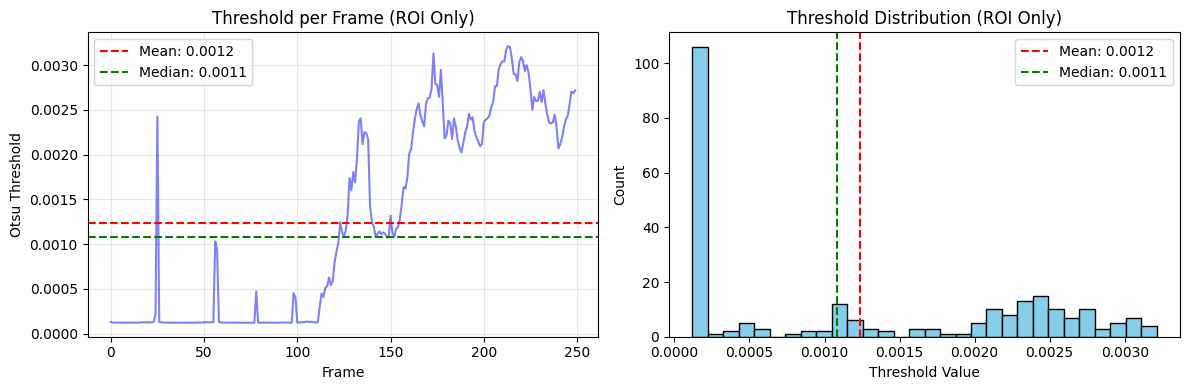

In [11]:
def otsu_threshold(frame_array, bins=256):
    values = frame_array[np.isfinite(frame_array)].astype(np.float32).ravel()
    if values.size == 0:
        raise ValueError("No valid pixels available for Otsu thresholding")
    hist, bin_edges = np.histogram(values, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    total = values.size
    sum_total = np.dot(hist, bin_centers)
    weight_background = 0.0
    sum_background = 0.0
    max_variance = 0.0
    threshold_value = float(bin_centers[0])
    for h, center in zip(hist, bin_centers):
        weight_background += h
        if weight_background == 0:
            continue
        weight_foreground = total - weight_background
        if weight_foreground == 0:
            break
        sum_background += h * center
        mean_background = sum_background / weight_background
        mean_foreground = (sum_total - sum_background) / weight_foreground
        between_variance = weight_background * weight_foreground * (mean_background - mean_foreground) ** 2
        if between_variance > max_variance:
            max_variance = between_variance
            threshold_value = center
    return threshold_value

# Compute Otsu across multiple frames, using ROI only
start_frame = 0
end_frame = 250

# Handle both 3D (NIfTI) and 4D (mp4) data
if image_data.pixel_data.ndim == 4:
    frames = image_data.pixel_data[:,:,:,0]
else:
    frames = image_data.pixel_data

seg_mask = seg_data.seg_mask

# First, let's check the raw data range in the ROI
print("Raw data diagnostics:")
print(f"  Data type: {frames.dtype}")
print(f"  Overall range: [{frames.min():.4f}, {frames.max():.4f}]")

# Check a sample ROI frame
sample_frame = frames[:, :, 150]
if seg_mask.ndim == 3 and seg_mask.shape[2] == frames.shape[2]:
    sample_roi_mask = seg_mask[:, :, 150]
else:
    sample_roi_mask = seg_mask
sample_roi_pixels = sample_frame[sample_roi_mask > 0]
print(f"  Sample ROI (frame 150) range: [{sample_roi_pixels.min():.4f}, {sample_roi_pixels.max():.4f}]")
print(f"  Sample ROI (frame 150) mean: {sample_roi_pixels.mean():.4f}")
print(f"  Sample ROI (frame 150) median: {np.median(sample_roi_pixels):.4f}")
print()

thresholds = []
for i in range(start_frame, end_frame):
    # Extract frame - NIfTI has time on third axis
    frame = np.asarray(frames[:, :, i], dtype=np.float32)
    
    # Extract corresponding ROI mask frame (if motion-corrected)
    if seg_mask.ndim == 3 and seg_mask.shape[2] == frames.shape[2]:
        roi_mask = seg_mask[:, :, i]
    else:
        roi_mask = seg_mask
    
    # Extract only ROI pixels
    roi_pixels = frame[roi_mask > 0]
    
    if roi_pixels.size > 0:
        thresh = otsu_threshold(roi_pixels)
        thresholds.append(thresh)

thresholds = np.array(thresholds)

# Statistics
print(f"Otsu threshold statistics across frames {start_frame}-{end_frame}:")
print(f"  Mean: {thresholds.mean():.4f}")
print(f"  Median: {np.median(thresholds):.4f}")
print(f"  Std: {thresholds.std():.4f}")
print(f"  Min: {thresholds.min():.4f}")
print(f"  Max: {thresholds.max():.4f}")

# Use median as optimal threshold
otsu_threshold_value = np.median(thresholds)
print(f"\nUsing median threshold: {otsu_threshold_value:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(start_frame, start_frame + len(thresholds)), thresholds, 'b-', alpha=0.5)
axes[0].axhline(thresholds.mean(), color='r', linestyle='--', label=f'Mean: {thresholds.mean():.4f}')
axes[0].axhline(np.median(thresholds), color='g', linestyle='--', label=f'Median: {np.median(thresholds):.4f}')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Otsu Threshold')
axes[0].set_title('Threshold per Frame (ROI Only)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(thresholds, bins=30, color='skyblue', edgecolor='black')
axes[1].axvline(thresholds.mean(), color='r', linestyle='--', label=f'Mean: {thresholds.mean():.4f}')
axes[1].axvline(np.median(thresholds), color='g', linestyle='--', label=f'Median: {np.median(thresholds):.4f}')
axes[1].set_xlabel('Threshold Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Threshold Distribution (ROI Only)')
axes[1].legend()

plt.tight_layout()
plt.show()

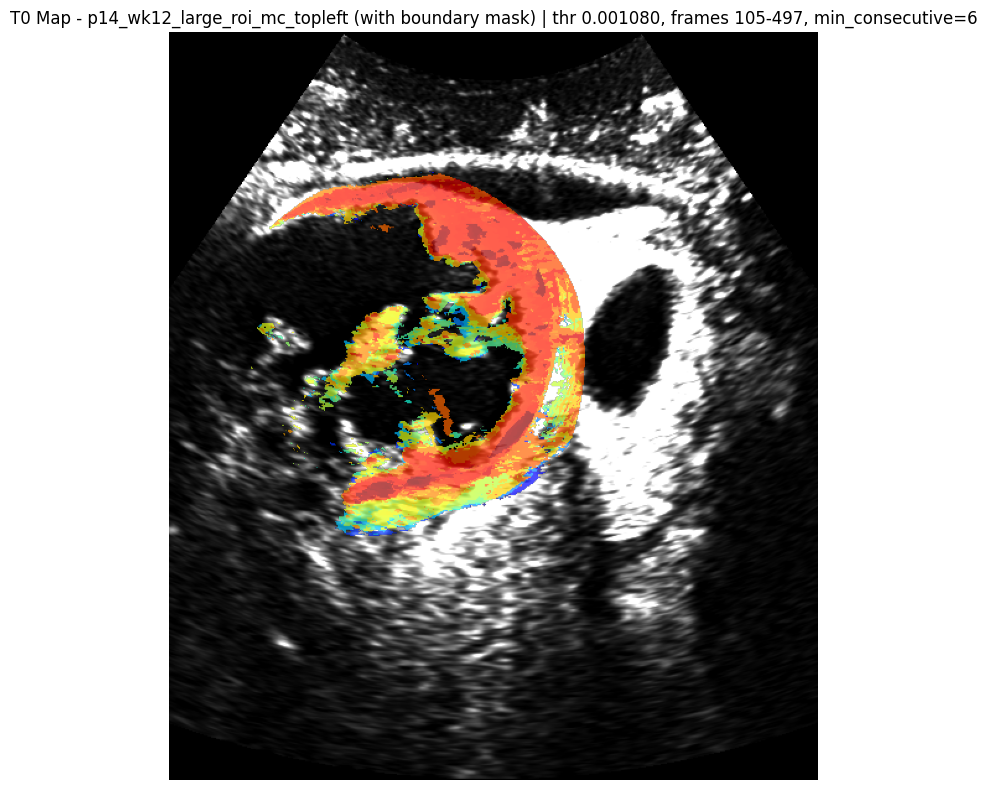


T0 Map Statistics:
  mean_t0: 293.65
  median_t0: 312.00
  std_t0: 60.65
  min_t0: 10.00
  max_t0: 382.00
  coverage: 43.88


In [21]:
from TwoD_CEUS_test.T0_map import generate_t0_map, get_t0_statistics, mask_t0_map

# Handle both 3D (NIfTI) and 4D (mp4) data
if image_data.pixel_data.ndim == 4:
    pixel_data_for_analysis = image_data.pixel_data[:,:,:,0]
else:
    # NIfTI has time on third axis, but generate_t0_map expects time on first axis
    # Transpose from (height, width, time) to (time, height, width)
    pixel_data_for_analysis = image_data.pixel_data.transpose(2, 0, 1)

# Generate the T0 map with temporal consistency filtering
threshold = float(otsu_threshold_value)  # Computed via Otsu
start_frame = 105
end_frame = 497
min_consecutive_frames = 6  # Require 3 consecutive frames above threshold (filters noise)

t0_map = generate_t0_map(
    pixel_data_for_analysis,
    seg_data.seg_mask,
    threshold=threshold,
    start_frame=start_frame,
    end_frame=end_frame,
    min_consecutive_frames=min_consecutive_frames
)

# Mask the T0 map to show only ROI
masked_t0_map = mask_t0_map(t0_map, seg_data.seg_mask)

# Make pixels that never enhanced transparent (set to NaN)
# THIS IS THE BASE VERSION - never modified, used by all subsequent cells
masked_t0_map_transparent = masked_t0_map.copy().astype(float)
masked_t0_map_transparent[masked_t0_map == 0] = np.nan

# ============== BOUNDARY MASK TOGGLE ==============
apply_boundary = True # Set to True to use boundary mask
# ==================================================

# Create visualization version (doesn't modify masked_t0_map_transparent)
t0_map_for_viz = masked_t0_map_transparent.copy()

# Apply boundary mask if enabled and available
if apply_boundary and USE_BOUNDARY_MASK and boundary_mask_2d is not None:
    t0_map_for_viz[~boundary_mask_2d] = np.nan
    boundary_status = ' (with boundary mask)'
else:
    boundary_status = ''

# Gamma correction
use_gamma = False      # <--- toggle this to True to enable
gamma = 0.8

if use_gamma:
    t0_map_for_viz = t0_map_for_viz ** (1/gamma)

# Build title with optional gamma value
gamma_str = f", gamma={gamma}" if use_gamma else ""
title = f'T0 Map - {seg_data.seg_name}{boundary_status} | thr {threshold:.6f}, frames {start_frame}-{end_frame}, min_consecutive={min_consecutive_frames}{gamma_str}'

# Get single frame for background - NIfTI has time on third axis originally
single_image = image_data.pixel_data[:, :, 250]

# Normalize single image for display
if single_image.dtype == np.float64:
    p20 = np.percentile(image_data.pixel_data, 20)
    p95 = np.percentile(image_data.pixel_data, 95)
    single_image_display = np.clip(single_image, p20, p95)
    single_image_display = ((single_image_display - p20) / (p95 - p20) * 255).astype(np.uint8)
else:
    single_image_display = single_image

# Visualize T0 map
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(single_image_display, cmap='gray')
ax.imshow(t0_map_for_viz, alpha=0.7, cmap='jet')
ax.set_title(title)
ax.axis('off')
plt.tight_layout()
plt.show()

# Get statistics
stats = get_t0_statistics(t0_map, seg_data.seg_mask)
print("\nT0 Map Statistics:")
for key, value in stats.items():
    print(f"  {key}: {value:.2f}")

Arrival frame ranges (threshold=0.0):
  Early: frames 115 - 168
  Middle: frames 168 - 205
  Late: frames 205 - 487


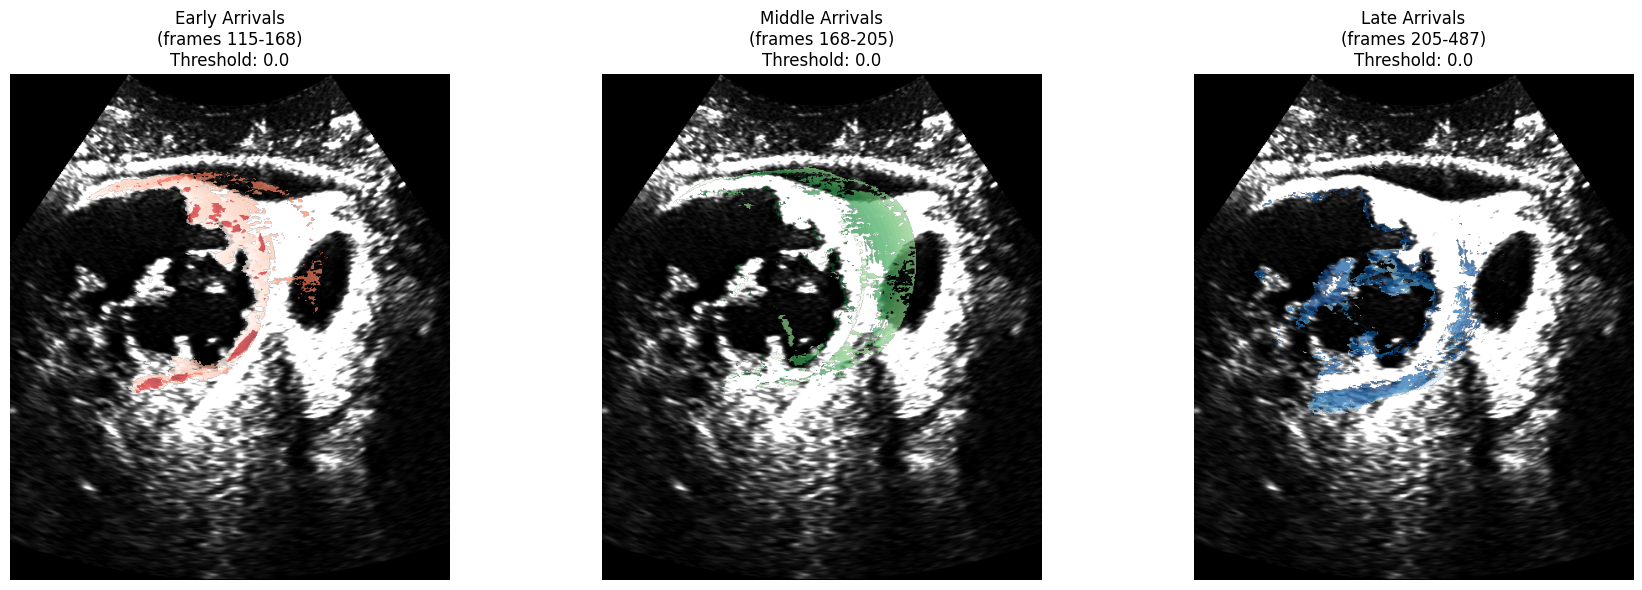

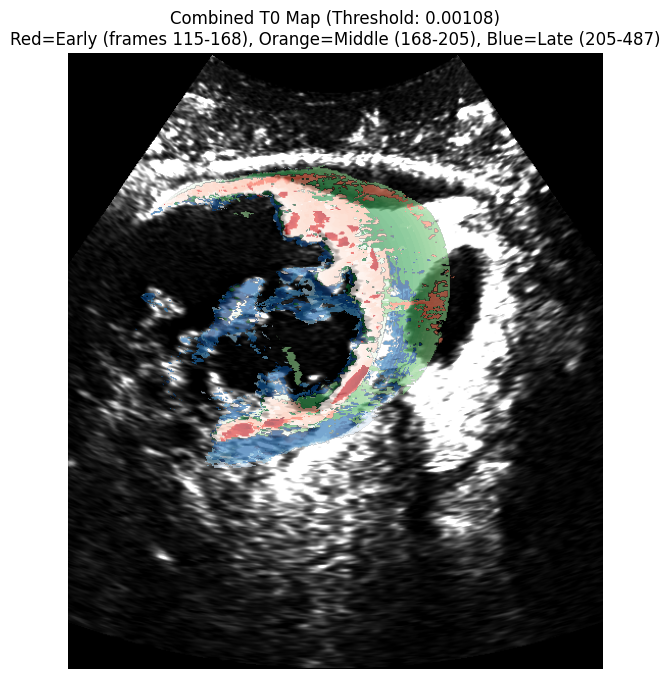

In [25]:
# Split T0 map into Early, Middle, and Late arrival groups
# Only consider pixels that actually enhanced (T0 > 0)
enhanced_pixels = masked_t0_map_transparent > 0
enhanced_pixels_clean = np.nan_to_num(enhanced_pixels, nan=False)

if np.any(enhanced_pixels_clean):
    # Get the T0 values for enhanced pixels only
    t0_values = masked_t0_map[enhanced_pixels_clean]
    
    # Calculate tertiles (split into 3 equal groups)
    tertile_33 = np.percentile(t0_values, 33.33)
    tertile_67 = np.percentile(t0_values, 66.67)
    
    # Convert T0 values back to actual frame numbers for display
    # T0 = end_frame - actual_frame, so actual_frame = end_frame - T0
    frame_max = end_frame - t0_values.min()  # Latest arrival
    frame_67 = end_frame - tertile_67  # Early/middle boundary
    frame_33 = end_frame - tertile_33  # Middle/late boundary
    frame_min = end_frame - t0_values.max()  # Earliest arrival
    
    print(f"Arrival frame ranges (threshold={threshold:.1f}):")
    print(f"  Early: frames {frame_min:.0f} - {frame_67:.0f}")
    print(f"  Middle: frames {frame_67:.0f} - {frame_33:.0f}")
    print(f"  Late: frames {frame_33:.0f} - {frame_max:.0f}")
    
    # Create three separate maps
    early_map = masked_t0_map_transparent.copy()
    early_map[masked_t0_map < tertile_67] = np.nan
    
    middle_map = masked_t0_map_transparent.copy()
    middle_map[(masked_t0_map < tertile_33) | (masked_t0_map >= tertile_67)] = np.nan
    
    late_map = masked_t0_map_transparent.copy()
    late_map[masked_t0_map >= tertile_33] = np.nan
    
    # Visualize all three
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Get single frame for background - NIfTI has time on third axis
    single_image = image_data.pixel_data[:, :, 250]
    
    # Normalize single image for display
    if single_image.dtype == np.float64:
        p20 = np.percentile(image_data.pixel_data, 20)
        p95 = np.percentile(image_data.pixel_data, 95)
        single_image_display = np.clip(single_image, p20, p95)
        single_image_display = ((single_image_display - p20) / (p95 - p20) * 255).astype(np.uint8)
    else:
        single_image_display = single_image
    
    # Early arrivals (highest T0 values = earliest)
    axes[0].imshow(single_image_display, cmap='gray')
    axes[0].imshow(early_map, alpha=0.7, cmap='Reds')
    axes[0].set_title(f'Early Arrivals\n(frames {frame_min:.0f}-{frame_67:.0f})\nThreshold: {threshold:.1f}')
    axes[0].axis('off')
    
    # Middle arrivals
    axes[1].imshow(single_image_display, cmap='gray')
    axes[1].imshow(middle_map, alpha=0.7, cmap='Greens')
    axes[1].set_title(f'Middle Arrivals\n(frames {frame_67:.0f}-{frame_33:.0f})\nThreshold: {threshold:.1f}')
    axes[1].axis('off')
    
    # Late arrivals (lowest T0 values = latest)
    axes[2].imshow(single_image_display, cmap='gray')
    axes[2].imshow(late_map, alpha=0.7, cmap='Blues')
    axes[2].set_title(f'Late Arrivals\n(frames {frame_33:.0f}-{frame_max:.0f})\nThreshold: {threshold:.1f}')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Combined overlay with all three
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(single_image_display, cmap='gray')
    ax.imshow(early_map, alpha=0.6, cmap='Reds')
    ax.imshow(middle_map, alpha=0.6, cmap='Greens')
    ax.imshow(late_map, alpha=0.6, cmap='Blues')
    ax.set_title(f'Combined T0 Map (Threshold: {threshold:.5f})\nRed=Early (frames {frame_min:.0f}-{frame_67:.0f}), Orange=Middle ({frame_67:.0f}-{frame_33:.0f}), Blue=Late ({frame_33:.0f}-{frame_max:.0f})')
    ax.axis('off')
    plt.show()
else:
    print("No enhanced pixels found!")

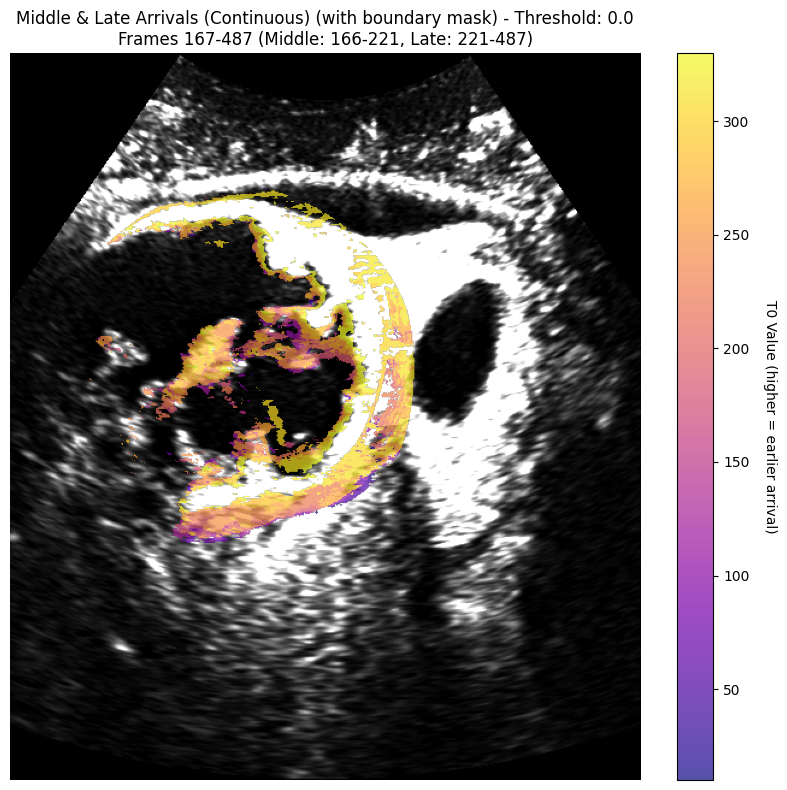


Pixel distribution:
  Early (excluded): 12772 pixels (13.7%)
  Middle (shown): 17188 pixels (18.5%)
  Late (shown): 63192 pixels (67.8%)

Showing 80380 of 93152 enhanced pixels (86.3%)


In [26]:
# Create continuous colormap for Middle and Late arrivals only
import matplotlib.colors as mcolors

# ============== BOUNDARY MASK TOGGLE ==============
apply_boundary = True  # Set to True to use boundary mask
# ==================================================

# Apply boundary mask if requested
t0_map_to_use = masked_t0_map_transparent.copy()
if apply_boundary and USE_BOUNDARY_MASK and boundary_mask_2d is not None:
    t0_map_to_use[~boundary_mask_2d] = np.nan
    boundary_status = ' (with boundary mask)'
else:
    boundary_status = ''

enhanced_pixels = t0_map_to_use > 0
enhanced_pixels_clean = np.nan_to_num(enhanced_pixels, nan=False)

if np.any(enhanced_pixels_clean):
    # Get the T0 values for enhanced pixels only
    t0_values = masked_t0_map[enhanced_pixels_clean]

    # Calculate tertiles
    tertile_33 = np.percentile(t0_values, 33.33)
    tertile_67 = np.percentile(t0_values, 66.67)

    # Convert to frame numbers for display
    frame_max = end_frame - t0_values.min()
    frame_67 = end_frame - tertile_67
    frame_33 = end_frame - tertile_33
    frame_min = end_frame - t0_values.max()

    # Create a map showing ONLY middle and late arrivals with continuous color
    # Filter out early arrivals (T0 >= tertile_67)
    middle_late_map = t0_map_to_use.copy()
    middle_late_map[masked_t0_map >= tertile_67] = np.nan  # Remove early arrivals

    # Get min/max for continuous colormap (only middle and late)
    middle_late_values = middle_late_map[~np.isnan(middle_late_map)]

    if middle_late_values.size > 0:
        vmin = middle_late_values.min()
        vmax = middle_late_values.max()

        # Convert T0 range to actual frame range
        frame_range_min = end_frame - vmax  # earliest of middle/late
        frame_range_max = end_frame - vmin  # latest of middle/late

        # Visualize with continuous colormap
        fig, ax = plt.subplots(figsize=(10, 8))

        # Get single frame for background - NIfTI has time on third axis
        single_image = image_data.pixel_data[:, :, 250]

        # Normalize single image for display
        if single_image.dtype == np.float64:
            p20 = np.percentile(image_data.pixel_data, 20)
            p95 = np.percentile(image_data.pixel_data, 95)
            single_image_display = np.clip(single_image, p20, p95)
            single_image_display = ((single_image_display - p20) / (p95 - p20) * 255).astype(np.uint8)
        else:
            single_image_display = single_image

        ax.imshow(single_image_display, cmap='gray')

        # Use continuous colormap - options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
        # 'plasma' and 'inferno' work well for medical imaging
        im = ax.imshow(middle_late_map, alpha=0.7, cmap='plasma', vmin=vmin, vmax=vmax)

        ax.set_title(f'Middle & Late Arrivals (Continuous){boundary_status} - Threshold: {threshold:.1f}\nFrames {frame_range_min:.0f}-{frame_range_max:.0f} (Middle: {frame_67:.0f}-{frame_33:.0f}, Late: {frame_33:.0f}-{frame_max:.0f})')
        ax.axis('off')

        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('T0 Value (higher = earlier arrival)', rotation=270, labelpad=20)

        plt.tight_layout()
        plt.show()

        # Print statistics
        n_middle = np.sum((masked_t0_map >= tertile_33) & (masked_t0_map < tertile_67))
        n_late = np.sum(masked_t0_map < tertile_33)
        n_early = np.sum(masked_t0_map >= tertile_67)
        total_enhanced = n_early + n_middle + n_late

        print(f"\nPixel distribution:")
        print(f"  Early (excluded): {n_early} pixels ({n_early/total_enhanced*100:.1f}%)")
        print(f"  Middle (shown): {n_middle} pixels ({n_middle/total_enhanced*100:.1f}%)")
        print(f"  Late (shown): {n_late} pixels ({n_late/total_enhanced*100:.1f}%)")
        print(f"\nShowing {n_middle + n_late} of {total_enhanced} enhanced pixels ({(n_middle + n_late)/total_enhanced*100:.1f}%)")
    else:
        print("No middle or late arrival pixels found!")
else:
    print("No enhanced pixels found!")

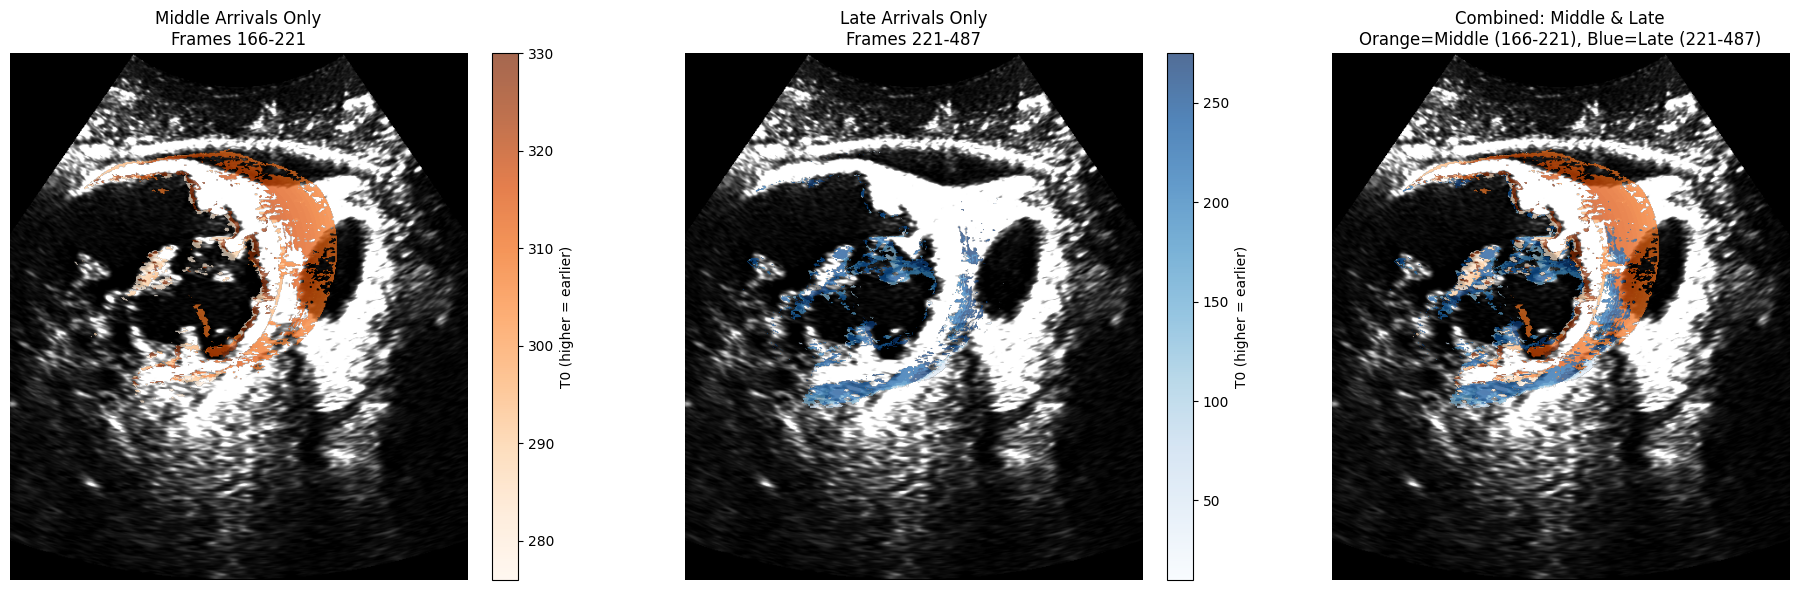


Pixel distribution:
  Early (excluded): 12772 pixels (31.2%)
  Middle (orange): 17188 pixels (42.1%)
  Late (blue): 10914 pixels (26.7%)


In [27]:
# Middle and Late with separate continuous colormaps for better differentiation
import matplotlib.colors as mcolors

# ============== BOUNDARY MASK TOGGLE ==============
apply_boundary = False  # Set to True to use boundary mask
# ==================================================

# Apply boundary mask if requested
t0_map_to_use = masked_t0_map_transparent.copy()
if apply_boundary and USE_BOUNDARY_MASK and boundary_mask_2d is not None:
    t0_map_to_use[~boundary_mask_2d] = np.nan
    boundary_status = ' (with boundary)'
else:
    boundary_status = ''

enhanced_pixels = t0_map_to_use > 0
enhanced_pixels_clean = np.nan_to_num(enhanced_pixels, nan=False)

if np.any(enhanced_pixels_clean):
    # Get the T0 values for enhanced pixels only
    t0_values_for_tertiles = t0_map_to_use[enhanced_pixels_clean]

    # Create separate maps for middle and late
    middle_map = t0_map_to_use.copy()
    middle_map[(t0_map_to_use < tertile_33) | (t0_map_to_use >= tertile_67)] = np.nan
    
    late_map = t0_map_to_use.copy()
    late_map[t0_map_to_use >= tertile_33] = np.nan

    # Get background image
    single_image = image_data.pixel_data[:, :, 250]
    if single_image.dtype == np.float64:
        p20 = np.percentile(image_data.pixel_data, 20)
        p95 = np.percentile(image_data.pixel_data, 95)
        single_image_display = np.clip(single_image, p20, p95)
        single_image_display = ((single_image_display - p20) / (p95 - p20) * 255).astype(np.uint8)
    else:
        single_image_display = single_image

    # Create figure with 3 subplots: Middle only, Late only, and Combined
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Middle only - use warm colors (Oranges)
    axes[0].imshow(single_image_display, cmap='gray')
    middle_values = middle_map[~np.isnan(middle_map)]
    if middle_values.size > 0:
        im1 = axes[0].imshow(middle_map, alpha=0.7, cmap='Oranges', vmin=middle_values.min(), vmax=middle_values.max())
        plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='T0 (higher = earlier)')
    axes[0].set_title(f'Middle Arrivals Only{boundary_status}\nFrames {frame_67:.0f}-{frame_33:.0f}')
    axes[0].axis('off')

    # Late only - use cool colors (Blues)
    axes[1].imshow(single_image_display, cmap='gray')
    late_values = late_map[~np.isnan(late_map)]
    if late_values.size > 0:
        im2 = axes[1].imshow(late_map, alpha=0.7, cmap='Blues', vmin=late_values.min(), vmax=late_values.max())
        plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='T0 (higher = earlier)')
    axes[1].set_title(f'Late Arrivals Only{boundary_status}\nFrames {frame_33:.0f}-{frame_max:.0f}')
    axes[1].axis('off')

    # Combined - orange for middle, blue for late
    axes[2].imshow(single_image_display, cmap='gray')
    if middle_values.size > 0:
        axes[2].imshow(middle_map, alpha=0.7, cmap='Oranges', vmin=middle_values.min(), vmax=middle_values.max())
    if late_values.size > 0:
        axes[2].imshow(late_map, alpha=0.7, cmap='Blues', vmin=late_values.min(), vmax=late_values.max())
    axes[2].set_title(f'Combined: Middle & Late{boundary_status}\nOrange=Middle ({frame_67:.0f}-{frame_33:.0f}), Blue=Late ({frame_33:.0f}-{frame_max:.0f})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Print statistics
    n_middle = np.sum((t0_map_to_use >= tertile_33) & (t0_map_to_use < tertile_67) & ~np.isnan(t0_map_to_use))
    n_late = np.sum((t0_map_to_use < tertile_33) & ~np.isnan(t0_map_to_use))
    n_early = np.sum((t0_map_to_use >= tertile_67) & ~np.isnan(t0_map_to_use))
    total_enhanced = n_early + n_middle + n_late

    print(f"\nPixel distribution:")
    print(f"  Early (excluded): {n_early} pixels ({n_early/total_enhanced*100:.1f}%)")
    print(f"  Middle (orange): {n_middle} pixels ({n_middle/total_enhanced*100:.1f}%)")
    print(f"  Late (blue): {n_late} pixels ({n_late/total_enhanced*100:.1f}%)")
else:
    print("No enhanced pixels found!")